In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/MR_project-main

/content/drive/MyDrive/MR_project-main


In [3]:
!pip install -q ultralytics transformers accelerate scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 5.1 MB/s eta 0:00:00


# YOLO11 vs YOLO26 — Final End-to-End Comparison

This notebook compares the **final output of the complete pipeline** using:

- YOLO11 + Depth Anything V2 + ROI classifier
- YOLO26 + Depth Anything V2 + ROI classifier

The same test set, depth model and `ROImodel.pt` are used for both pipelines.

## Evaluation protocol

The comparison is performed at **frame level**:

- `y_true = 1` if a TTI annotation exists for the frame
- `y_true = 0` otherwise
- `y_pred = 1` if at least one ROI produced by the pipeline is classified as class `1`
- `y_pred = 0` otherwise

This isolates the effect of changing the YOLO front-end while keeping the rest of the pipeline unchanged.


In [4]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt

from ultralytics import YOLO
from transformers import pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Device: cuda:0


## Paths

In [5]:
from pathlib import Path

TEST_IMAGES_DIR = Path("/content/drive/MyDrive/yolo_dataset/images/test")
TTI_LABELS_DIR  = Path("/content/drive/MyDrive/yolo_dataset/tti_labels/test")

YOLO11_PATH = "/content/drive/MyDrive/MR_project-main/outputs/yolo11/best11.pt"
YOLO26_PATH = "/content/drive/MyDrive/MR_project-main/outputs/yolo26/best26.pt"
ROI_MODEL_PATH = "/content/drive/MyDrive/MR_project-main/ROImodel.pt"

assert TEST_IMAGES_DIR.exists(), f"Missing: {TEST_IMAGES_DIR}"
assert TTI_LABELS_DIR.exists(), f"Missing: {TTI_LABELS_DIR}"
assert Path(YOLO11_PATH).exists(), f"Missing: {YOLO11_PATH}"
assert Path(YOLO26_PATH).exists(), f"Missing: {YOLO26_PATH}"
assert Path(ROI_MODEL_PATH).exists(), f"Missing: {ROI_MODEL_PATH}"


In [6]:
print("TEST IMAGES:", TEST_IMAGES_DIR.exists())
print("TTI LABELS:", TTI_LABELS_DIR.exists())
print("YOLO11:", Path(YOLO11_PATH).exists())
print("YOLO26:", Path(YOLO26_PATH).exists())
print("ROI:", Path(ROI_MODEL_PATH).exists())

TEST IMAGES: True
TTI LABELS: True
YOLO11: True
YOLO26: True
ROI: True


## ROI classifier

Loads the pre-trained ROI classifier shared by both pipelines.

In [7]:
class ROIClassifier(nn.Module):
    def __init__(self, num_hoi_classes):
        super().__init__()

        self.first = nn.Conv2d(5, 4, kernel_size=1, stride=1, padding=0, bias=False)
        self.pre_conv = nn.Conv2d(4, 3, kernel_size=1, stride=1, padding=0, bias=False)

        self.backbone = models.resnet18(pretrained=True)
        self.backbone.fc = nn.Identity()

        self.fc = nn.Linear(512, num_hoi_classes)

    def forward(self, x):
        x = self.first(x)
        x = self.pre_conv(x)
        features = self.backbone(x)
        out = F.sigmoid(self.fc(features))
        return out


roi_classifier = ROIClassifier(2)
roi_classifier.load_state_dict(torch.load(ROI_MODEL_PATH, map_location=DEVICE))
roi_classifier.to(DEVICE)
roi_classifier.eval()

print("ROI classifier loaded.")


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 132MB/s]


ROI classifier loaded.


## Shared pipeline functions

Defines the common functions used to process YOLO detections and generate tool–tissue candidate ROIs.

In [8]:
tool_classes = list(range(0, 12))


def found_objects(tool_list, tti_list, classes):
    tool_found = []
    tti_found = []

    for elem in range(len(classes)):
        if classes[elem] in tool_list:
            tool_found.append(elem)
        if classes[elem] in tti_list:
            tti_found.append(elem)

    return tool_found, tti_found


def parse_yolo_output(result):
    r = result[0]

    if len(r.boxes.cls) == 0:
        return []

    if r.masks is None:
        return []

    if len(r.boxes.cls) < 2:
        return [{
            "class": int(r.boxes.cls[0].cpu().detach().numpy()),
            "mask": r.masks.data[0].cpu().detach().numpy()
        }]

    tool_list = list(range(0, 12))
    tti_list = list(range(12, 21))

    classes = r.boxes.cls
    masks = r.masks.data

    tool_found, tti_found = found_objects(tool_list, tti_list, classes)

    if len(tool_found) == 0:
        return [
            {
                "class": int(r.boxes.cls[idx].cpu().detach().numpy()),
                "mask": r.masks.data[idx].cpu().detach().numpy()
            }
            for idx in tti_found
        ]

    if len(tti_found) == 0:
        return [
            {
                "class": int(r.boxes.cls[idx].cpu().detach().numpy()),
                "mask": r.masks.data[idx].cpu().detach().numpy()
            }
            for idx in tool_found
        ]

    res = []

    for idx_tti in tti_found:
        for idx_tool in tool_found:
            tissue_mask = masks[idx_tti]
            tool_mask = masks[idx_tool]

            tti_dict = {
                "class": int(classes[idx_tti].cpu().detach().numpy()),
                "mask": tissue_mask.int().cpu().detach().numpy()
            }

            tool_dict = {
                "class": int(classes[idx_tool].cpu().detach().numpy()),
                "mask": tool_mask.int().cpu().detach().numpy()
            }

            if not any(
                elem["class"] == tti_dict["class"] and np.array_equal(elem["mask"], tti_dict["mask"])
                for elem in res
            ):
                res.append(tti_dict)

            if not any(
                elem["class"] == tool_dict["class"] and np.array_equal(elem["mask"], tool_dict["mask"])
                for elem in res
            ):
                res.append(tool_dict)

    return res


def yolo_inference(model, image_path):
    output = model.predict(str(image_path), verbose=False)
    return parse_yolo_output(output)


def find_tool_tissue_pairs(detections):
    tools = [d for d in detections if d["class"] in tool_classes]
    tissues = [d for d in detections if d["class"] not in tool_classes]

    pairs = []
    for tool in tools:
        for tissue in tissues:
            pairs.append({"tool": tool, "tissue": tissue})

    return pairs


def extract_union_roi(image, tool_mask, tissue_mask, depth_map=None):
    combined_mask = (tool_mask + tissue_mask).clip(0, 1).astype("uint8")

    if combined_mask.max() == 0:
        return None

    x, y, w, h = cv2.boundingRect(combined_mask)

    if w == 0 or h == 0:
        return None

    roi = image[y:y+h, x:x+w]

    if roi.size == 0:
        return None

    if depth_map is not None:
        depth_roi = depth_map[y:y+h, x:x+w]
        roi = np.concatenate([roi, depth_roi[..., None]], axis=-1)

    merged_mask = cv2.bitwise_or(
        tool_mask.astype(np.uint8),
        tissue_mask.astype(np.uint8)
    )
    merged_mask = merged_mask[y:y+h, x:x+w]
    merged_mask = np.expand_dims(merged_mask, axis=-1)

    if merged_mask.shape[:2] != roi.shape[:2]:
        return None

    roi = np.concatenate([roi, merged_mask * 255], axis=-1)
    return roi


## Load the two YOLO models and Depth Anything

In [9]:
yolo11 = YOLO(YOLO11_PATH)
yolo26 = YOLO(YOLO26_PATH)

depth_model = pipeline(
    task="depth-estimation",
    model="depth-anything/Depth-Anything-V2-Small-hf",
    device=0 if torch.cuda.is_available() else -1
)

print("Models loaded.")


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 99.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

Models loaded.


## Ground-truth helper

Defines the binary frame-level ground truth based on the presence of TTI annotations.

In [10]:
def get_frame_ground_truth(image_path):
    """
    Frame-level ground truth:
    1 if the corresponding tti_labels file contains at least one annotation,
    0 otherwise.
    """
    label_path = TTI_LABELS_DIR / f"{image_path.stem}.txt"

    if not label_path.exists():
        return 0

    text = label_path.read_text(encoding="utf-8").strip()
    return 1 if text else 0


## End-to-end prediction for one frame

Runs the complete pipeline on a single frame and produces the final tool–tissue interaction prediction.

In [11]:
def predict_frame(image_path, yolo_model):
    detections = yolo_inference(yolo_model, image_path)
    pairs = find_tool_tissue_pairs(detections)

    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        return 0, 0, []

    depth = np.array(depth_model(str(image_path))["depth"])

    # Match depth size to the image size used for ROI extraction
    H, W = image_bgr.shape[:2]
    if depth.shape[:2] != (H, W):
        depth = cv2.resize(depth, (W, H), interpolation=cv2.INTER_LINEAR)

    predictions = []

    for pair in pairs:
        tool_mask = pair["tool"]["mask"]
        tissue_mask = pair["tissue"]["mask"]

        if tool_mask.shape[:2] != (H, W):
            tool_mask = cv2.resize(
                tool_mask.astype(np.uint8),
                (W, H),
                interpolation=cv2.INTER_NEAREST
            )

        if tissue_mask.shape[:2] != (H, W):
            tissue_mask = cv2.resize(
                tissue_mask.astype(np.uint8),
                (W, H),
                interpolation=cv2.INTER_NEAREST
            )

        roi = extract_union_roi(
            image_bgr,
            tool_mask,
            tissue_mask,
            depth
        )

        if roi is None:
            continue

        roi_tensor = (
            torch.from_numpy(roi)
            .permute(2, 0, 1)
            .unsqueeze(0)
            .float() / 255.0
        )

        roi_tensor = F.interpolate(
            roi_tensor,
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).to(DEVICE)

        with torch.no_grad():
            output = roi_classifier(roi_tensor)

        pred_class = torch.argmax(output, dim=1).item()

        # Keep the model output associated with the predicted class.
        pred_score = output[0, pred_class].item()

        predictions.append({
            "tti_class": pred_class,
            "tti_score": pred_score,
            "tool_class": pair["tool"]["class"],
            "tissue_class": pair["tissue"]["class"]
        })

    # Frame-level prediction:
    # positive if at least one ROI is classified as class 1.
    frame_pred = int(any(p["tti_class"] == 1 for p in predictions))

    return frame_pred, len(predictions), predictions


## Run both pipelines on the same test set

In [12]:
image_extensions = {".png", ".jpg", ".jpeg", ".bmp"}

test_images = sorted(
    p for p in TEST_IMAGES_DIR.iterdir()
    if p.suffix.lower() in image_extensions
)

print("Test images:", len(test_images))

rows = []

for idx, image_path in enumerate(test_images, start=1):
    y_true = get_frame_ground_truth(image_path)

    try:
        pred11, n_roi11, _ = predict_frame(image_path, yolo11)
        error11 = ""
    except Exception as e:
        pred11 = 0
        n_roi11 = 0
        error11 = repr(e)

    try:
        pred26, n_roi26, _ = predict_frame(image_path, yolo26)
        error26 = ""
    except Exception as e:
        pred26 = 0
        n_roi26 = 0
        error26 = repr(e)

    rows.append({
        "image": image_path.name,
        "y_true": y_true,
        "yolo11_pred": pred11,
        "yolo26_pred": pred26,
        "yolo11_n_roi": n_roi11,
        "yolo26_n_roi": n_roi26,
        "yolo11_error": error11,
        "yolo26_error": error26,
    })

    if idx % 10 == 0 or idx == len(test_images):
        print(f"{idx}/{len(test_images)}")

results_df = pd.DataFrame(rows)
results_df.to_csv("yolo11_vs_yolo26_frame_predictions.csv", index=False)

results_df.head()


Test images: 182


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


10/182
20/182
30/182
40/182
50/182
60/182
70/182
80/182
90/182
100/182
110/182
120/182
130/182
140/182
150/182
160/182
170/182
180/182
182/182


,image,y_true,yolo11_pred,yolo26_pred,yolo11_n_roi,yolo26_n_roi,yolo11_error,yolo26_error
0,adnansetlc100009_frame000000.png,0,0,0,0,0,,
1,adnansetlc100009_frame000058.png,1,1,0,1,0,,
2,adnansetlc105008_frame000142.png,1,1,1,2,2,,
3,adnansetlc106001_frame000000.png,1,0,0,0,0,,
4,adnansetlc106001_frame000082.png,1,1,0,1,0,,


## Prediction Distribution and Error Check

In [13]:
print("Ground-truth distribution:")
display(results_df["y_true"].value_counts().sort_index())

print("\nYOLO11 prediction distribution:")
display(results_df["yolo11_pred"].value_counts().sort_index())

print("\nYOLO26 prediction distribution:")
display(results_df["yolo26_pred"].value_counts().sort_index())

print("\nFrames with YOLO11 errors:", (results_df["yolo11_error"] != "").sum())
print("Frames with YOLO26 errors:", (results_df["yolo26_error"] != "").sum())


Ground-truth distribution:


,count
y_true,
0,39
1,143



YOLO11 prediction distribution:


,count
yolo11_pred,
0,47
1,135



YOLO26 prediction distribution:


,count
yolo26_pred,
0,85
1,97



Frames with YOLO11 errors: 0
Frames with YOLO26 errors: 0


## Final metrics

Computes and compares Accuracy, Precision, Recall, F1-score, and Specificity for both pipelines.

In [14]:
def compute_binary_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
    }


m11 = compute_binary_metrics(
    results_df["y_true"],
    results_df["yolo11_pred"]
)

m26 = compute_binary_metrics(
    results_df["y_true"],
    results_df["yolo26_pred"]
)

metric_names = ["Accuracy", "Precision", "Recall", "F1-score", "Specificity"]

comparison = pd.DataFrame({
    "Metric": metric_names,
    "YOLO11 pipeline": [m11[m] for m in metric_names],
    "YOLO26 pipeline": [m26[m] for m in metric_names],
})

comparison["Delta (YOLO26 - YOLO11)"] = (
    comparison["YOLO26 pipeline"] - comparison["YOLO11 pipeline"]
)

comparison


,Metric,YOLO11 pipeline,YOLO26 pipeline,Delta (YOLO26 - YOLO11)
0,Accuracy,0.802198,0.681319,-0.120879
1,Precision,0.896296,0.938144,0.041848
2,Recall,0.846154,0.636364,-0.209790
3,F1-score,0.870504,0.758333,-0.112170
4,Specificity,0.641026,0.846154,0.205128


## Confusion counts

In [15]:
confusion_counts = pd.DataFrame({
    "Outcome": ["True Positive", "True Negative", "False Positive", "False Negative"],
    "YOLO11": [m11["TP"], m11["TN"], m11["FP"], m11["FN"]],
    "YOLO26": [m26["TP"], m26["TN"], m26["FP"], m26["FN"]],
})

confusion_counts


,Outcome,YOLO11,YOLO26
0,True Positive,121,91
1,True Negative,25,33
2,False Positive,14,6
3,False Negative,22,52


## Confusion matrices

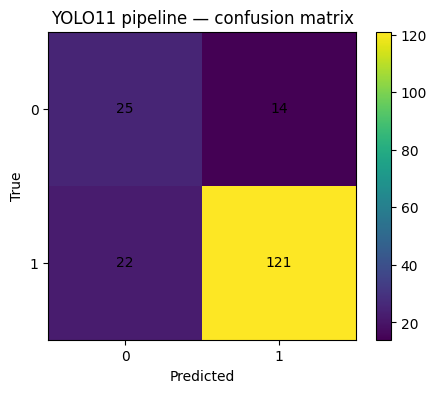

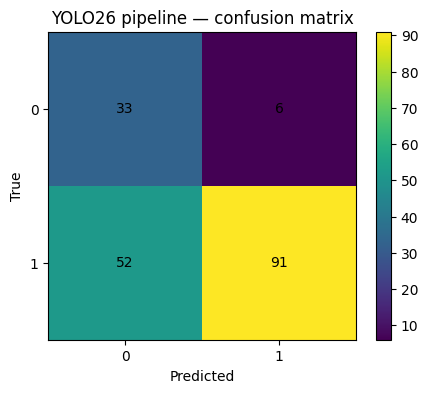

In [16]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar(im)
    plt.show()


plot_confusion(
    results_df["y_true"],
    results_df["yolo11_pred"],
    "YOLO11 pipeline — confusion matrix"
)

plot_confusion(
    results_df["y_true"],
    results_df["yolo26_pred"],
    "YOLO26 pipeline — confusion matrix"
)


## Classification reports

In [17]:
print("YOLO11 PIPELINE")
print(
    classification_report(
        results_df["y_true"],
        results_df["yolo11_pred"],
        labels=[0, 1],
        target_names=["Class 0", "Class 1"],
        zero_division=0
    )
)

print("\nYOLO26 PIPELINE")
print(
    classification_report(
        results_df["y_true"],
        results_df["yolo26_pred"],
        labels=[0, 1],
        target_names=["Class 0", "Class 1"],
        zero_division=0
    )
)


YOLO11 PIPELINE
              precision    recall  f1-score   support

     Class 0       0.53      0.64      0.58        39
     Class 1       0.90      0.85      0.87       143

    accuracy                           0.80       182
   macro avg       0.71      0.74      0.73       182
weighted avg       0.82      0.80      0.81       182


YOLO26 PIPELINE
              precision    recall  f1-score   support

     Class 0       0.39      0.85      0.53        39
     Class 1       0.94      0.64      0.76       143

    accuracy                           0.68       182
   macro avg       0.66      0.74      0.65       182
weighted avg       0.82      0.68      0.71       182



## Frames where the two pipelines disagree

In [18]:
disagreements = results_df[
    results_df["yolo11_pred"] != results_df["yolo26_pred"]
].copy()

print("Number of disagreements:", len(disagreements))
disagreements


Number of disagreements: 48


,image,y_true,yolo11_pred,yolo26_pred,yolo11_n_roi,yolo26_n_roi,yolo11_error,yolo26_error
1,adnansetlc100009_frame000058.png,1,1,0,1,0,,
4,adnansetlc106001_frame000082.png,1,1,0,1,0,,
5,adnansetlc106001_frame000150.png,1,1,0,2,0,,
15,adnansetlc120007_frame000068.png,0,1,0,2,0,,
18,adnansetlc125001_frame000024.png,1,0,1,0,2,,
19,adnansetlc125001_frame000150.png,1,1,0,4,0,,
21,adnansetlc126005_frame000032.png,1,1,0,2,0,,
29,adnansetlc145002_frame000005.png,0,1,0,1,0,,
30,adnansetlc145010_frame000034.png,0,1,0,2,0,,
32,adnansetlc156002_frame000000.png,1,1,0,1,0,,


## Export Results

In [19]:
comparison.to_csv("final_metrics_yolo11_vs_yolo26.csv", index=False)
confusion_counts.to_csv("final_confusion_counts_yolo11_vs_yolo26.csv", index=False)
disagreements.to_csv("final_disagreements_yolo11_vs_yolo26.csv", index=False)

print("Saved:")
print("- yolo11_vs_yolo26_frame_predictions.csv")
print("- final_metrics_yolo11_vs_yolo26.csv")
print("- final_confusion_counts_yolo11_vs_yolo26.csv")
print("- final_disagreements_yolo11_vs_yolo26.csv")


Saved:
- yolo11_vs_yolo26_frame_predictions.csv
- final_metrics_yolo11_vs_yolo26.csv
- final_confusion_counts_yolo11_vs_yolo26.csv
- final_disagreements_yolo11_vs_yolo26.csv


## Interpretation

The end-to-end comparison shows that YOLO11 provides better overall performance for tool–tissue contact detection.

YOLO11 achieves higher Accuracy (80.2%), Recall (84.6%), and F1-score (87.1%), while YOLO26 achieves higher Precision (93.8%) and Specificity (84.6%).

YOLO26 therefore behaves more conservatively, producing fewer false positives but missing a larger number of actual tool–tissue interactions. Overall, YOLO11 provides the better trade-off for the considered end-to-end pipeline.